In [4]:
import dgrec
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from Bio.Data import CodonTable

In [7]:
plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})

# Fig 5 (a)

/home/regnier/miniconda3/envs/lstm_new/lib/python3.12/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Original sequence: TGCTAAAGAGGCATTCGAACGTCACGGCATCGATGCGCATCGTTACGGTTTCTTATGCTTTGACTCTTGGGACGATGTGTACGAAGAGGATGC
Amino acid sequence: AKEAFERHGIDAHRYGFLCFDSWDDVYEED


Text(0, 0.5, 'Avd+TR+Sp \n score')

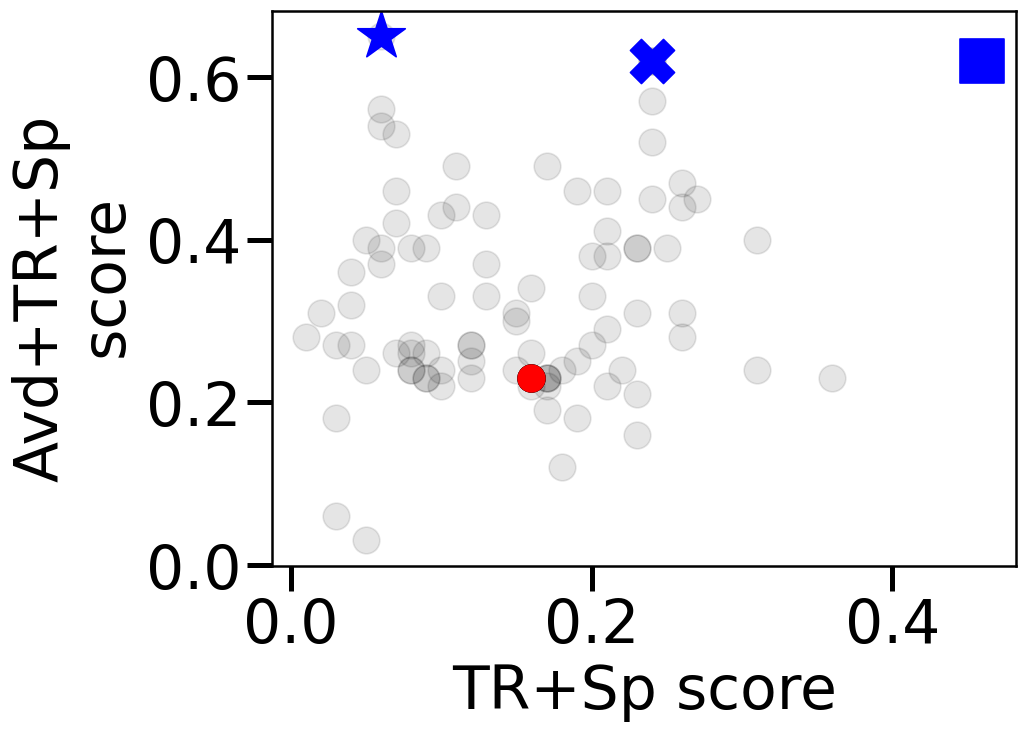

In [9]:
tr='TGCTAAAGAGGCATTCGAACGTCACGGCATCGATGCGCATCGTTACGGTTTCTTATGCTTTGACTCTTGGGACGATGTGTACGAAGAGGATGC'
score_init=dgrec.predictions.score(tr,features=2)


tr_sequence=tr
dna_seq = Seq(tr)[1:]

# Use the standard genetic code
standard_table = CodonTable.unambiguous_dna_by_id[1]

# Translate the sequence
amino_acids = dna_seq.translate()

# Function to get all synonym codons for an amino acid
def get_synonym_codons(amino_acid):
    synonyms = []
    for codon, aa in standard_table.forward_table.items():
        if aa == amino_acid:
            synonyms.append(codon)
    return synonyms

# Generate all single-codon synonym variants
variants = []
for i in range(1, len(tr_sequence)-1, 3):
    codon = tr_sequence[i:i+3]
    if len(codon) == 3:
        amino_acid = dna_seq[i:i+3].translate()
        synonym_codons = get_synonym_codons(amino_acid)
        for synonym in synonym_codons:
            if synonym != codon:
                new_seq = tr_sequence[:i] + synonym + tr_sequence[i+3:]
                variants.append(new_seq)

# Print all variants
print("Original sequence:", tr_sequence)
print("Amino acid sequence:", amino_acids)

Scores=[dgrec.predictions.score(var,features=2) for var in variants]

def find_non_dominated_indices(Scores):
    n = len(Scores)
    non_dominated = []
    for i in range(n):
        x, y = Scores[i]
        dominated = False
        for j in range(n):
            if i == j:
                continue
            x_prime, y_prime = Scores[j]
            if x_prime > x and y_prime > y:
                dominated = True
                break
        if not dominated:
            non_dominated.append(i)
    return non_dominated
best_variants0=find_non_dominated_indices(Scores)

X0=[a for [a,b] in Scores]
Y0=[b for [a,b] in Scores]
plt.scatter(X0,Y0,c='k',alpha=0.1)
plt.scatter([X0[b] for b in best_variants0[:1]],[Y0[b] for b in best_variants0[:1]], marker='*',c='blue',s=900)
plt.scatter([X0[b] for b in best_variants0[1:2]],[Y0[b] for b in best_variants0[1:2]], marker='s',c='blue',s=700)
plt.scatter([X0[b] for b in best_variants0[2:3]],[Y0[b] for b in best_variants0[2:3]], marker='X',c='blue',s=700)

plt.scatter([score_init[0]],[score_init[1]],c='r')
plt.xlabel('TR+Sp score')
plt.ylabel('Avd+TR+Sp \n score')

## Fig 5 (b)

Text(0, 0.5, 'Avd+TR+Sp \n score')

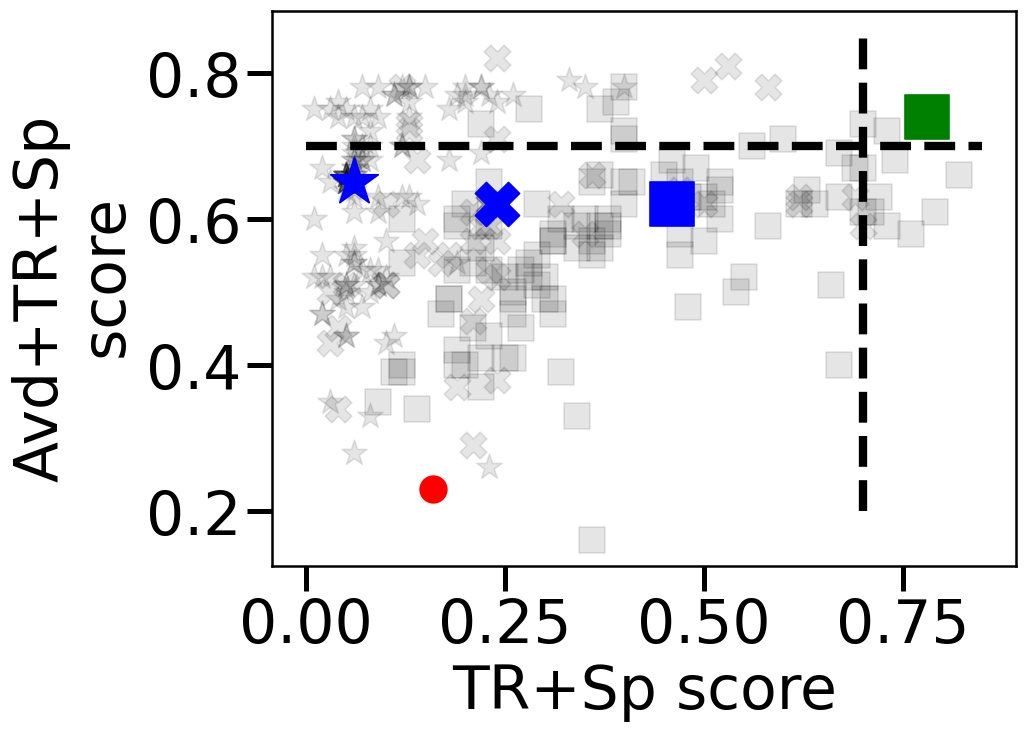

In [10]:
tr_variants=[variants[b] for b in best_variants0[:3]] # Take the Three best sequences of first step for the second step
variants = []
for tr_sequence in tr_variants:
    for i in range(1, len(tr_sequence)-1, 3):
        codon = tr_sequence[i:i+3]
        if len(codon) == 3:
            amino_acid = dna_seq[i:i+3].translate()
            synonym_codons = get_synonym_codons(amino_acid)
            for synonym in synonym_codons:
                if synonym != codon:
                    new_seq = tr_sequence[:i] + synonym + tr_sequence[i+3:]
                    variants.append(new_seq)
Scores=[dgrec.predictions.score(var,features=2) for var in variants]
best_variants=find_non_dominated_indices(Scores)

mark=['*','s','X']
X=[a for [a,b] in Scores]
Y=[b for [a,b] in Scores]
Delta=len(variants)//3
for i in range(3):
   plt.scatter(X[Delta*i:Delta*(i+1)],Y[Delta*i:Delta*(i+1)],c='k',marker=mark[i],alpha=0.1)
plt.scatter([score_init[0]],[score_init[1]],c='r')
plt.scatter([X[b] for b in best_variants[:1]],[Y[b] for b in best_variants[:1]], c='green',marker='s',s=700)

plt.scatter([X0[b] for b in best_variants0[:1]],[Y0[b] for b in best_variants0[:1]], marker='*',c='blue',s=900)
plt.scatter([X0[b] for b in best_variants0[1:2]],[Y0[b] for b in best_variants0[1:2]], marker='s',c='blue',s=700)
plt.scatter([X0[b] for b in best_variants0[2:3]],[Y0[b] for b in best_variants0[2:3]], marker='X',c='blue',s=700)

plt.plot([0.7,0.7],[0.2,0.85],'--k')
plt.plot([0.,0.85],[0.7,0.7],'--k')
plt.xlabel('TR+Sp score')
plt.ylabel('Avd+TR+Sp \n score')

# Fig 5 (d)

In [29]:
df=pd.read_csv('../Summary_all.csv')
#Library 1
df1=df[df['Library']=="Lib_1"]
filtered_df1 = df1[['TR', 'percentage_mutants']]
# Group by 'TR' and calculate the average of 'percentage_mutants'
grouped_df1 = filtered_df1.groupby('TR')['percentage_mutants'].mean().reset_index()
#Library 2
df2=df[df['Library']=="Lib_2"]
filtered_df2 = df2[['TR', 'percentage_mutants']]
# Group by 'TR' and calculate the average of 'percentage_mutants'
grouped_df2 = filtered_df2.groupby('TR')['percentage_mutants'].mean().reset_index()
#Library 3
good_df=pd.read_csv('Lib3_Good.csv')
recoded_df=pd.read_csv('Lib3_Recoded.csv')
bad_df=pd.read_csv('Lib3_Bad.csv')
df3=pd.concat([good_df, recoded_df], axis=0, ignore_index=True)
filtered_df3 = df3[['TR', 'percentage_mutants']]
# Group by 'TR' and calculate the average of 'percentage_mutants'
grouped_df3 = filtered_df3.groupby('TR')['percentage_mutants'].mean().reset_index()

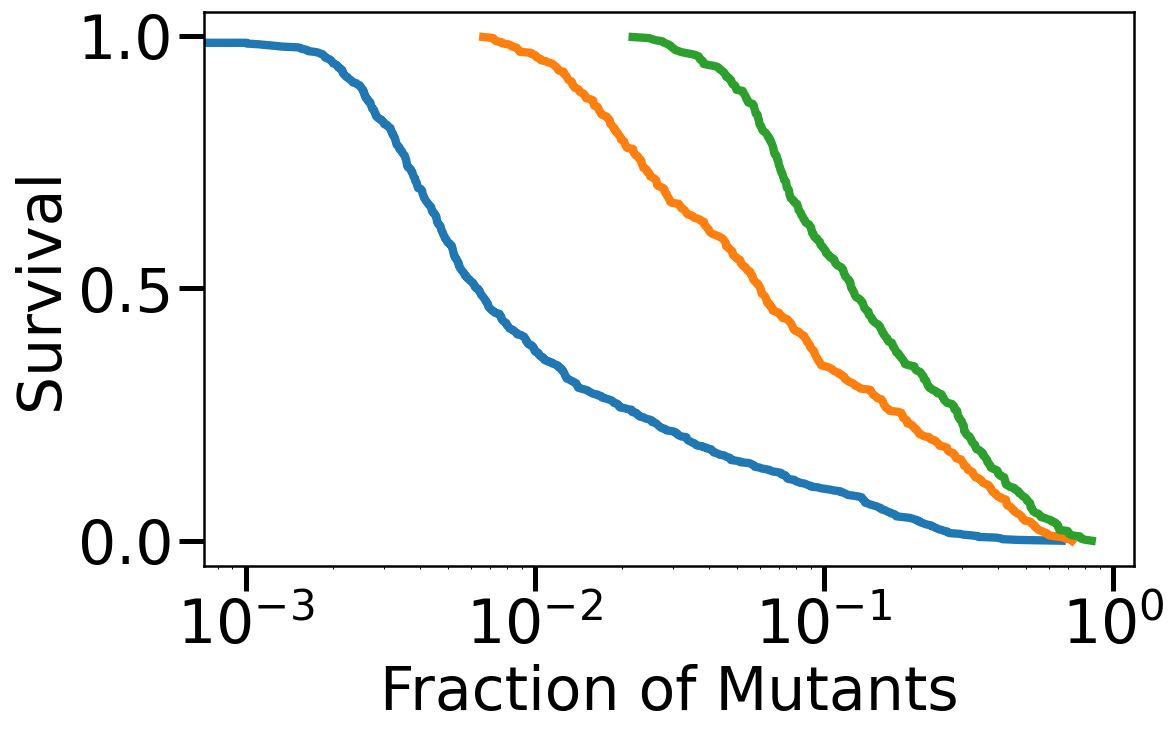

In [30]:
# Plot tail distributions for all libraries
plt.figure(figsize=(10,6))
data=list(grouped_df1['percentage_mutants'])
sorted_data = np.sort(data)
sf = 1 - np.arange(1, len(sorted_data)+1)/len(sorted_data)
plt.plot(sorted_data/100, sf, label='Lib 1')

data=list(grouped_df2['percentage_mutants'])
sorted_data = np.array(list(np.sort(data)))
sf = 1 - np.arange(1, len(sorted_data)+1)/len(sorted_data)
plt.plot(sorted_data/100, sf, label='Lib 2')

data=list(grouped_df3['percentage_mutants'])
sorted_data = np.array(list(np.sort(data)))
sf = 1 - np.arange(1, len(sorted_data)+1)/len(sorted_data)
plt.plot(sorted_data/100, sf, label='Lib 3')

plt.semilogx()

plt.xscale('log')
plt.xlabel('Fraction of Mutants')
plt.ylabel('Survival')

# Fig 5 (e)

In [31]:
def base_name(name):
    if pd.isna(name):
        return None
    return (
        name.replace('Recoded', '')
            .replace('Bad', '')
            .strip('_- ')
    )

recoded_df['base'] = recoded_df['template_name'].apply(base_name)
bad_df['base'] = bad_df['template_name'].apply(base_name)

# ---------- Aggregate percentage_dgrec per template ----------
recoded_percentage = (
    recoded_df
    .groupby('base')['percentage_mutants']
    .mean()
)

bad_percentage = (
    bad_df
    .groupby('base')['percentage_mutants']
    .mean()
)

# ---------- Pair Recoded vs Bad ----------
comparison = pd.DataFrame({
    'recoded': recoded_percentage,
    'bad': bad_percentage
}).dropna()

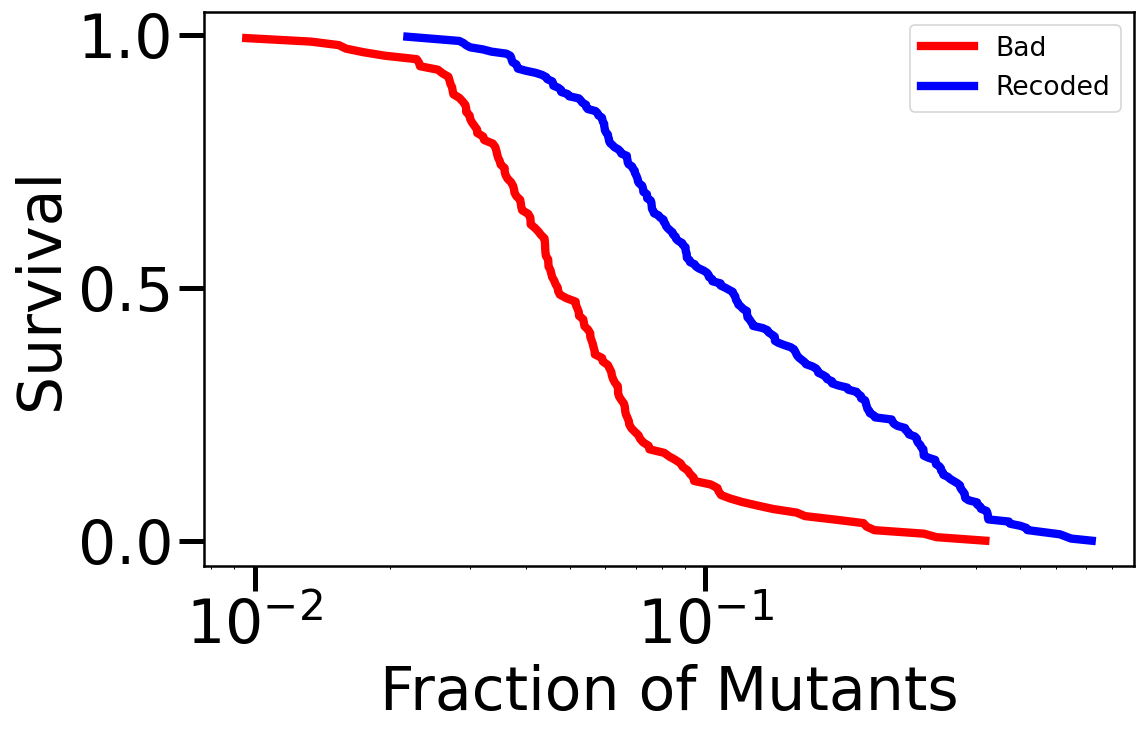

In [32]:
plt.figure(figsize=(10,6))

sorted_data = np.sort(list(bad_df['percentage_mutants']))
sf = 1 - np.arange(1, len(sorted_data)+1)/len(sorted_data)
plt.plot(sorted_data/100, sf,'r', label='Bad')

sorted_data = np.sort(list(recoded_df['percentage_mutants']))
sf = 1 - np.arange(1, len(sorted_data)+1)/len(sorted_data)
plt.plot(sorted_data/100, sf,'b', label='Recoded')




plt.legend()
plt.semilogx()

plt.xscale('log')
plt.xlabel('Fraction of Mutants')
plt.ylabel('Survival')
plt.legend()
plt.show()